In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, FunctionTransformer

In [2]:
df=pd.read_csv("final_database.csv")
df.shape

(5546, 29)

In [3]:
binary_columns = ['jobma_catcher_status',
                  'jobma_catcher_type',
                  'is_premium',
                  'subscription_type_x',
                  'referral_credit',
                  'ai_live_interview',
                  'subscription_type_y',
                  'plan_type',
                  'is_unlimited',
                  'currency'
                 ]

categorical_columns = ['subscription_status',
                       'per_sub_user',
                       'company_size',
                      ]
                   
ordinal_columns = ['sub_user',#
                   'days_since_creation',#
                   'number_of_logins',#
                   'days_since_login',#
                   'wallet_sum',#
                   'subscription_sum',#
                   'subscription_count',#
                   'ai_kit_counts',#
                   'pre_recorded_kit_counts',#
                   'number_of_jobs_posted',#
                   'number_of_pitcher_invitations',#
                   'number_of_pitchers_applied',#
                   'pre_rec_interviews_counts',#
                   'live_interviews_counts',#
                   'ai_interviews_counts',#done
                   ]

In [4]:
def clean_binary(X):
    return X.apply(lambda col: col.map(lambda val: 1 if str(val).strip().lower() in ['1', 'true', 'yes'] else 0))

def clean_categorical(X):
    return X.apply(lambda col: col.map(
        lambda val: str(val).strip().lower() if pd.notnull(val) and str(val).strip() else 'others'))

def clean_ordinal(X):
    return X.where(X >= 0, np.nan)

In [5]:
# Pipelines
binary_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_binary, validate=False)),
                                  ('imputer', SimpleImputer(strategy='most_frequent'))
                                 ])

categorical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_categorical, validate=False)),
                                       ('imputer', SimpleImputer(strategy='most_frequent')),
                                       ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
                                      ])

ordinal_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_ordinal, validate=False)),
                                   ('imputer', SimpleImputer(strategy='median')),
                                   ('scaler', RobustScaler())
                                  ])


In [6]:
# Combine preprocessors
preprocessor = ColumnTransformer(transformers=[('bin', binary_pipeline, binary_columns),
                                               ('cat', categorical_pipeline, categorical_columns),
                                               ('ord', ordinal_pipeline, ordinal_columns)],
                                 verbose_feature_names_out=False)


# Final pipeline
pipeline = Pipeline(steps=[('preprocessing', preprocessor)])

In [7]:
preprocessor

ColumnTransformer(transformers=[('bin',
                                 Pipeline(steps=[('cleaner',
                                                  FunctionTransformer(func=<function clean_binary at 0x000001CC4430F880>)),
                                                 ('imputer',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['jobma_catcher_status', 'jobma_catcher_type',
                                  'is_premium', 'subscription_type_x',
                                  'referral_credit', 'ai_live_interview',
                                  'subscription_type_y', 'plan_type',
                                  'is_unli...
                                 ['sub_user', 'days_since_creation',
                                  'number_of_logins', 'days_since_login',
                                  'wallet_sum', 'subscription_sum',
                                  'subscription_count', 'ai_kit_counts',
                                  'pre_recorded_kit_counts',
                                  'number_of_jobs_posted',
                                  'number_of_pitcher_invitations',
                                  'number_of_pitchers_applied',
                                  'pre_rec_interviews_counts',
                                  'live_interviews_counts',
                                  'ai_interviews_counts'])],
                  verbose_feature_names_out=False)

In [8]:
df_without_catcher_id = df.drop(columns=['catcher_id'])
X = pipeline.fit_transform(df_without_catcher_id)

In [9]:
X = pipeline.fit_transform(df)

In [10]:
###########################################################################################################################################################

In [11]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
kmeans = KMeans(n_clusters=63, random_state=42)
clusters = kmeans.fit_predict(X)

# Add the cluster label to the DataFrame
df['cluster'] = clusters

# Example: Recommend similar clients (same cluster) for the first client (index 0)
client_index = 0
client_cluster = df.loc[client_index, 'cluster']
similar_clients = df[df['cluster'] == client_cluster]
print("Recommended similar clients:")
print(similar_clients)

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

Recommended similar clients:
   catcher_id  jobma_catcher_status  jobma_catcher_type  is_premium  \
0          92                   1.0                   1         1.0   

   subscription_status  sub_user per_sub_user  subscription_type_x  \
0                    2       105          100                    0   

   referral_credit company_size  ...  currency  ai_kit_counts  \
0                0         1-25  ...       0.0            NaN   

   pre_recorded_kit_counts  number_of_jobs_posted  \
0                      2.0                  825.0   

   number_of_pitcher_invitations  number_of_pitchers_applied  \
0                            7.0                     17640.0   

   pre_rec_interviews_counts  live_interviews_counts  ai_interviews_counts  \
0                        3.0                     2.0                   NaN   

   cluster  
0        3  

[1 rows x 30 columns]


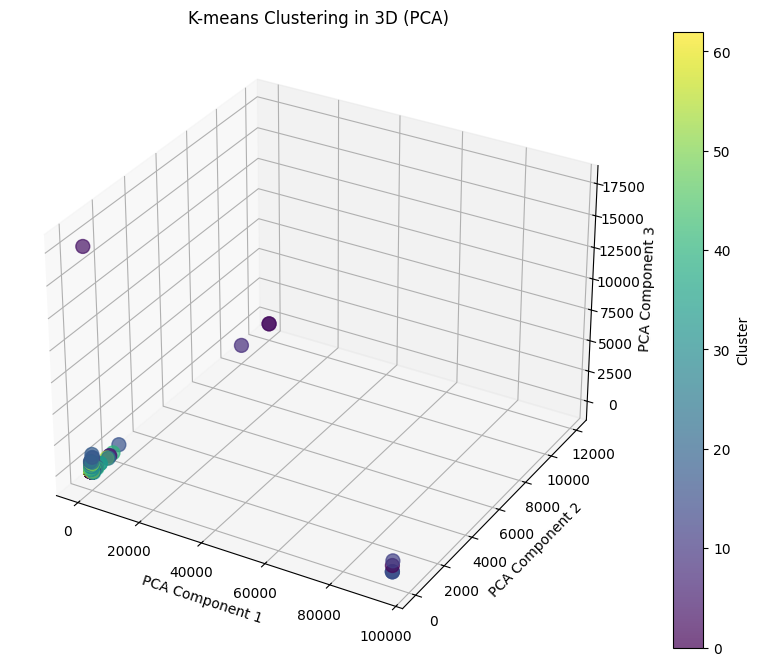

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

# Visualize the clusters in 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot in 3D
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=clusters, cmap='viridis', s=100, alpha=0.7)

# Labels and title
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('K-means Clustering in 3D (PCA)')

# Show color bar
fig.colorbar(scatter, ax=ax, label='Cluster')

# Show plot
plt.show()


In [14]:
import pandas as pd

# DataFrame with the cluster labels
df['cluster'] = clusters

# Size of each cluster
cluster_sizes = df['cluster'].value_counts().sort_index()

# the size of each cluster
print("Cluster Sizes:\n", cluster_sizes)


Cluster Sizes:
 cluster
0     4529
1        1
2        2
3        1
4      770
      ... 
58       4
59       1
60       2
61      54
62       2
Name: count, Length: 63, dtype: int64


In [15]:
inertia = kmeans.inertia_
print(f"Inertia: {inertia}")

Inertia: 310436.9960556703


In [16]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X, clusters)
print(f"Silhouette Score: {sil_score}")

Silhouette Score: 0.8446379076750666
